<a href="https://colab.research.google.com/github/HenryZumaeta/py4cd_EPC2025/blob/main/C16/C16_Script01_EstadisticaInferencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Interés: Interesección entre la **Estadística Inferencial** y el **Método Científico**

- La prueba de hipótesis no es solo un procedimiento mecánico; es el mecanismo de control de calidad del conocimiento humano.

# El Falsacionismo de Popper: En la intersección de la epistemología, la matemática aplica y la ingeniería de software.

  * Inducción: Si (Cisne blanco): Observar que mil no garantiza la regla
  * Falsación: Si (Un solo cisne negro), entonces la ley es falsa por MODUS TOLLENS

  1. P -> Q
  2. ~Q

  => Por lo tanto: ~P

  > Interpretación Intuitiva: `Si una causa fuera cierta, su efecto debería manifestarse`. `El efecto no se manifiesta. Luego, la causa no ocurrió`.

  > Aplicación en Machine Learning: El inductivismo es el peligro del overfitting. Un modelo puede "confirmar" su eficacia en el subconjunto de entrenamiento, pero la ciencia real ocurre en el Out-of-Distribution (OOO).

  - Deterctar OOD:
    * Umbrales de confianza (Max softMax Probability): Si la probabilidad de la clase ganadora es muy baja, se marca como OOD. Sin embargo, esto no siempre funciona por el problema de exceso de confianza.

    * Métodos Bayesianos: En lugar de una respuesta única, el modelo ofrece una distribución de respuestas. Si las respuestas varían mucho entre sí, hay alta incertidumbre => **Señal de OOD**

    * Modelos Generativos: Entrenar una red (como un VAC o GAN) para aprender cómo "se ven" los datos de entrenamiento. Si un dato nuevo es muy costoso de reconstruir, probablemente sea un OOD.



## Puntos clave

A. **Criterio de demarcación**: Para que un algoritmo de IA sea considerado científico, debe permitir auditoría de sus fallos.

* Modelos Transparentes (White-box)
* Modelos Opacos (Deep Learning)

B. **Corroboración**: En Ingeniería de Datos, la **Corroboración** es equivalente a la validación cruzada.

C. **Ciclo Iterativo**:
  * Problema: El modelo actual tiene un sesgo (bias) en una población específica.
  * Conjetura: Una nueva arquitectura de red neuronal o una nueva técnica de regularización.
  * Falsazación: Pruebas de estrés y/o Inteligencias Artificiales Adversarias.
  * Nueva teoría: Un modelo más robusto que sobrevive a los ataques donde el anterior falló.

## Simulación

Simulemos un sistema de evaluación de políticas públicas, donde el modelo predice el éxito de una intervención social.


In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.utils import resample

# Simular datos: Impacto de programas de becas (X) en ingresos futuros (y)
X = np.random.normal(10, 2, (100,1))
y = 2.5 * X.flatten() + np.random.normal(0, 5, 100)

# Conjetura: El coeficietne de impacto es exactamente 2.5
# Estrategia: Falsar la estabilidad del coeficeinte mediante Bootstraping

coefs = []
for i in range(1000):
    X_res, y_res = resample(X,y)
    model = Ridge().fit(X_res, y_res)
    coefs.append(model.coef_[0])


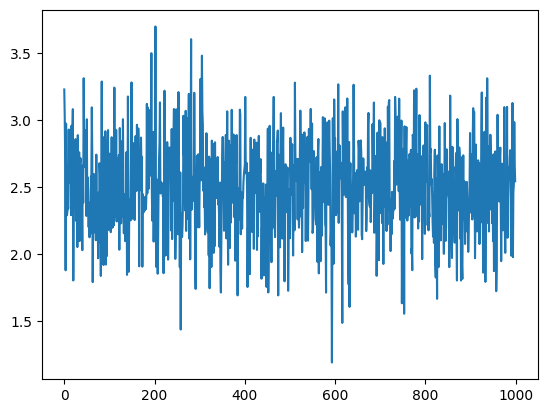

In [7]:
import matplotlib.pyplot as plt
plt.plot(coefs)

In [9]:
# Análisis de falsación
np.percentile(coefs, [2.5, 97.5])
# Intervalo de confianza al 95% para el impacto

array([1.81696812, 3.1744596 ])

## Arquitectura del Pipeline de Falsación
  * Ingesta de datos: Usar/seleccionar un dataset
  * Desarrollar una estrategia de entrenamiento multimodelo
  * Test de hipótesis automatizados
    * Test de Significancia: ¿El modelo es realmente mejor que un predictor aleatorio?
    * Test de Sesgo (Fairness): ¿El error es significativamente mayor para ciertos segmentos de datos?
    * Test de Robustez (Falsación de estabilidad): ¿Cambia el coeficiente con pequeñas perturbaciones?

# Definiciones formales

- Hipótesis Nulas: Postula que el parámetro poblacional es igual a un valor nulo.
- Hipótesis Alternativas: Es el complemento en el espacio paramétrico.


## Comparación de medias (T-test)

Imagina que hemos desplegado un modelo de procesacimiento de lenguaje natural (NLP) para agilizar trámites ciudadanos. Queremos saber si el tiempo de respuesta disminuyó.

### Análisis del diseño experimental y metodológico (Enfoque Frecuentista)

**Contexto del problema**

  - Variable dependiente: Tiempo de respuesta (en segundos)  
  - Intervención: Implementación de un modelo NLP
  - Diseño: Comparación entre grupos independientes (antes vs después)
  - Tamaño muestral: n1 = n2 = 8  (muestras relativamente pequeña)

**Hipótesis**
- **$H_0$**: $\mu_{\text{antes}} = \mu_{\text{después}}$ (No hay reducción significativa)
- **$H_1$**: $\mu_{\text{después}} < \mu_{\text{antes}}$ (El modelo NLP agiliza los trámites ciudadanos)
- **Nivel de significancia**: $\alpha = 0.05$

> La estadística básica nos dice que la prueba a utilizar es: **Prueba de t student para muestras independiente**.

> El uso de esta prueba es apropiado si se cumplen los supuestos:
  - Independencia: Asumido por diseño
  - Normalidad: Pasar por un supuesto de verificación
  - Homocedasticidad: Pasar por un proceso de verificación


### Análisis del diseño experimental y metodológico (Enfoque Bayesiano)

**Análisis metodológico**
- Parámetro de interés: Tasa de éxito
- Distribución a-priori: $Beta(\alpha = 2, \beta = 2)$
- Verosimilitud: Bernoulli
- Distribución posterior: $Beta(\alpha = \alpha + éxitos, \beta = \beta + fracasos)$

## Prueba de Independencia (Chi-Cuadrado): Sesgo en algoritmos

Deseamos evaluar si un algorítmo de asignación de subsidios es independiente del género del solicitante.

### Análisis metodológico del diseño experimental

**Estructura del problema**

  - Variable independiente (categórica): Género del solicitante (A vs B)
  - Variable dependiente (Categórica): Decisión del algorítmo (Aprobado vs Rechazado)
  - Diseño: Tabla de contingencia $2 \times 2$
  - Tamaño muestral: N = 450 + 150 + 430 + 170 = 1200

**Hipótesis**
- **$H_0$**: Decisión del algoritmo es independiente del género (no hay sesgo)
- **$H_1$**: Decisión del algoritmo es dependiente del género (hay sesgo)
- **Nivel de significancia**: $\alpha = 0.05$

**Elección de la prueba estadística**
  - Elegimos la prueba Chi-cuadrado de Pearson


# Errores del Tipo I y errores del Tipo II

- Error Tipo I ($ \alpha$): Falso positivo

$$
P(\text{Rechazar} H_0 | H_0 \text{sea verdadera}) = \alpha
$$

> Características: Rechar la hipótesis nula cuando en realidad es verdadera

- Error Tipo II ($\beta$): Falso negativo

$$
P(\text{No rechazar} H_0 | H_1 \text{es verdadera}) = \beta
$$

> Característica: No rechazar $H_0$ cuando la hipótesis alternativa ($H_1$) es verdadera